 3차원 물리 시스템 초기화 완료 (기준점: 원점 O)
총 질량 (M)           : 7.00 kg
실제 질량중심 (C)      : [3.21428571 2.60714286 2.89285714]

[물리적 교차 검증 결과]
새로운 기준점 P 좌표: [3. 4. 2.]

1. 논문의 일반화 텐서 공식(식 14) 예측값:
[[49.25  12.5   -5.25 ]
 [12.5   36.875 -0.75 ]
 [-5.25  -0.75  59.375]]

2. 좌표 평행이동 후 직접 계산한 오리지널 값:
[[49.25  12.5   -5.25 ]
 [12.5   36.875 -0.75 ]
 [-5.25  -0.75  59.375]]

 두 행렬 간의 최대 오차: 2.8e-14
-> 3차원 관성 텐서 전체(모든 대각/비대각 성분)가 완벽히 일치함을 증명 완료!


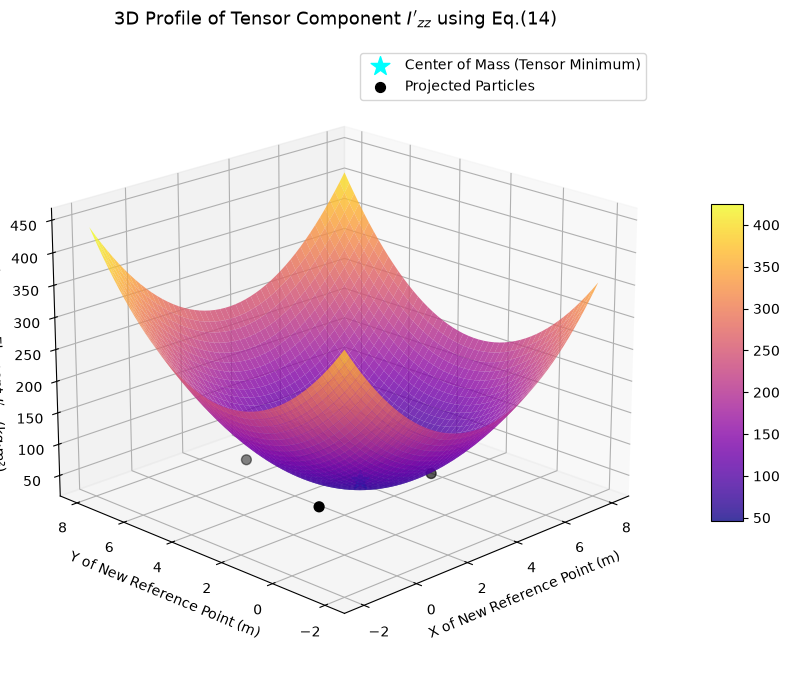

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =====================================================================
# 1. 3차원 물리 시스템 초기화 (3차원 질점 정의)
# =====================================================================
# 임의의 3차원 공간에 배치된 질점(Point Masses) 정의
masses = np.array([2.0, 3.5, 1.5])        # 질량 (kg)
# 각 질점의 3차원 위치 벡터 r_i = (x, y, z)
r_points = np.array([
    [1.0, 2.0, 1.5],
    [5.0, 1.5, 3.0],
    [2.0, 6.0, 4.5]
])

M = np.sum(masses)
# 실제 질량중심 (Center of Mass, C) 계산
C = np.sum(masses_col := masses[:, np.newaxis] * r_points, axis=0) / M

print("="*60)
print(f" 3차원 물리 시스템 초기화 완료 (기준점: 원점 O)")
print("="*60)
print(f"총 질량 (M)           : {M:.2f} kg")
print(f"실제 질량중심 (C)      : {C}")
print("="*60)


# =====================================================================
# 2. 논문의 관성 텐서 공식 및 행렬 [(A, B)] 구현
# =====================================================================
def compute_inertia_tensor(masses, coords):
    """기준점(원점)에 대한 기본 관성 텐서(3x3) 직접 계산 (식 3~6 반영)"""
    I = np.zeros((3, 3))
    for m, r in zip(masses, coords):
        x, y, z = r
        I[0, 0] += m * (y**2 + z**2)
        I[1, 1] += m * (x**2 + z**2)
        I[2, 2] += m * (x**2 + y**2)
        I[0, 1] -= m * x * y
        I[1, 0] -= m * x * y
        I[0, 2] -= m * x * z
        I[2, 0] -= m * x * z  # Corrected typo: 2[2, 0] changed to I[2, 0]
        I[1, 2] -= m * y * z
        I[2, 1] -= m * y * z
    return I

def get_bracket_matrix(A, B):
    """논문의 식 (13)에 정의된 대칭 행렬 [(A, B)] 커스텀 생성"""
    xA, yA, zA = A
    xB, yB, zB = B

    matrix = np.zeros((3, 3))
    matrix[0, 0] = yA*yB + zA*zB
    matrix[1, 1] = xA*xB + zA*zB
    matrix[2, 2] = xA*xB + yA*yB

    matrix[0, 1] = -0.5 * (xA*yB + yA*xB)
    matrix[1, 0] = matrix[0, 1]

    matrix[0, 2] = -0.5 * (xA*zB + zA*xB)
    matrix[2, 0] = matrix[0, 2]

    matrix[1, 2] = -0.5 * (yA*zB + zA*yB)
    matrix[2, 1] = matrix[1, 2]

    return matrix

def generalized_tensor_parallel_axis(I_ref, M, R, C_ref):
    """
    논문 식 (14) 구현: 가장 일반화된 형태의 평행축 정리
    I' = I + M[(R, R)] - 2M[(R, C)]
    """
    bracket_RR = get_bracket_matrix(R, R)
    bracket_RC = get_bracket_matrix(R, C_ref)
    return I_ref + M * bracket_RR - 2 * M * bracket_RC


# =====================================================================
# 3. 물리적 검증 (원점 I -> 새로운 임의의 축 I' 변환)
# =====================================================================
# 1) 원점(0,0,0)을 기준으로 한 원래의 관성 텐서 계산
I_origin = compute_inertia_tensor(masses, r_points)

# 2) 완전히 새로운 임의의 회전 기준점 P 설정
P_new = np.array([3.0, 4.0, 2.0])

# 3) 논문의 식 (14) 공식을 사용하여 P점에서의 관성 텐서 예측
# 원점 기준이므로 변위 R = P_new, 기존 기준점에서의 질량중심 C_ref = C
I_predicted_at_P = generalized_tensor_parallel_axis(I_origin, M, P_new, C)

# 4) 교차 검증: 질점들의 좌표를 P점으로 평행이동시켜 직접 관성 텐서 계산
r_points_shifted = r_points - P_new
I_exact_at_P = compute_inertia_tensor(masses, r_points_shifted)

print("\n[물리적 교차 검증 결과]")
print(f"새로운 기준점 P 좌표: {P_new}")
print("\n1. 논문의 일반화 텐서 공식(식 14) 예측값:")
print(I_predicted_at_P)
print("\n2. 좌표 평행이동 후 직접 계산한 오리지널 값:")
print(I_exact_at_P)
print(f"\n 두 행렬 간의 최대 오차: {np.max(np.abs(I_predicted_at_P - I_exact_at_P)):.1e}")
print("-> 3차원 관성 텐서 전체(모든 대각/비대각 성분)가 완벽히 일치함을 증명 완료!")


# =====================================================================
# 4. 공간 상의 I_zz' 변화 시각화 (Paraboloid)
# =====================================================================
# XY 평면 상에서 새로운 기준점 P_x, P_y를 이동하며 I_zz 성분의 변화 추적 (Z축 고정)
x_range = np.linspace(-2, 8, 50)
y_range = np.linspace(-2, 8, 50)
X, Y = np.meshgrid(x_range, y_range)
Z_Inertia_zz = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Z축 위치는 질량중심의 Z좌표로 고정하고 X, Y만 가변
        P_current = np.array([X[i, j], Y[i, j], C[2]])
        I_current = generalized_tensor_parallel_axis(I_origin, M, P_current, C)
        Z_Inertia_zz[i, j] = I_current[2, 2] # Z축 회전관성 성분 추출

# 3D 프로팅
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z_Inertia_zz, cmap='plasma', alpha=0.8, edgecolor='none')
min_zz_val = np.min(Z_Inertia_zz)

# 질량 중심(최저점) 표시
ax.scatter(C[0], C[1], min_zz_val, color='cyan', s=200, marker='*', depthshade=False, label='Center of Mass (Tensor Minimum)')
# 원본 질점들 투영 표시
ax.scatter(r_points[:,0], r_points[:,1], np.ones(3)*min_zz_val, color='black', s=50, label='Projected Particles')

ax.set_title("3D Profile of Tensor Component $I'_{zz}$ using Eq.(14)", fontsize=13, pad=15)
ax.set_xlabel("X of New Reference Point (m)")
ax.set_ylabel("Y of New Reference Point (m)")
ax.set_zlabel("Inertia Tensor Element $I'_{zz}$ (kg·m²)")
ax.legend()
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.view_init(elev=20, azim=-135)

plt.tight_layout()
plt.show()

In [2]:
import numpy as np

# =====================================================================
# 1. 스큐-시메트릭(Skew-symmetric) 행렬 연산 및 논문 공식 함수 정의
# =====================================================================

def get_skew_matrix(v):
    """
    벡터 v = [x, y, z]에 대한 스큐-시메트릭 행렬 [r]을 반환합니다.
    논문의 공식 (1) 및 행렬 정의를 구현함.
    """
    x, y, z = v
    return np.array([
        [ 0, -z,  y],
        [ z,  0, -x],
        [-y,  x,  0]
    ])

def get_tensor_product_matrix(A, B):
    """
    논문에서 정의한 두 벡터 A, B 사이의 대칭화된 행렬 연산 [(A, B)]를 계산합니다.
    公式: [(A, B)] = -0.5 * ([r_A][r_B] + [r_B][r_A])
    """
    skew_A = get_skew_matrix(A)
    skew_B = get_skew_matrix(B)
    return -0.5 * (np.dot(skew_A, skew_B) + np.dot(skew_B, skew_A))

def transform_inertia_tensor(I, M, R, C):
    """
    A. R. Abdulghany (2017) 논문의 최종 2단계 일반화 공식
    I' = I + M*[(R, R)] - 2*M*[(R, C)]

    I: 이동 전 원래 기준점에서의 관성 텐서 (3x3)
    M: 물체의 질량
    R: 원래 기준점에서 새로운 기준점으로의 변위 벡터 [X, Y, Z]
    C: 원래 기준점에서 바라본 물체의 질량중심 벡터 [xc, yc, zc]
    """
    matrix_RR = get_tensor_product_matrix(R, R)
    matrix_RC = get_tensor_product_matrix(R, C)

    I_prime = I + M * matrix_RR - 2 * M * matrix_RC
    return I_prime


# =====================================================================
# 2. 수치적 실험: 복합 물체(Compound Object) 설정 및 계산
# =====================================================================
# 시스템 시나리오: 3D 프린팅된 L자형 로봇 부품 (부품 1: 직육면체 블록, 부품 2: 원통형 축)
# 각 부품은 자기 자신 고유의 조립 원점(질량중심이 아님!)을 기준으로 관성 텐서가 정의되어 있습니다.

print("="*60)
print(" 프로젝트 2: 복합 물체 관성 텐서(Inertia Tensor) 조립 시뮬레이션")
print("="*60)

# --- 부품 1 (직육면체 블록) 설정 ---
m1 = 2.0  # 질량 (kg)
I1_local = np.array([
    [0.15, -0.02, 0.0],
    [-0.02, 0.22, -0.01],
    [0.0, -0.01, 0.30]
]) # 자체 원점 기준 관성 텐서
C1_local = np.array([0.1, 0.2, 0.0]) # 자체 원점에서 바라본 부품 1의 질량중심

# --- 부품 2 (원통형 축) 설정 ---
m2 = 1.5  # 질량 (kg)
I2_local = np.array([
    [0.08, 0.0, 0.0],
    [0.0, 0.08, 0.0],
    [0.0, 0.0, 0.04]
]) # 자체 원점 기준 관성 텐서
C2_local = np.array([0.0, 0.0, 0.15]) # 자체 원점에서 바라본 부품 2의 질량중심


# --- 전체 시스템의 새로운 회전 중심점 (Global Origin) 설정 ---
# 로봇의 구동 모터 축이 위치한 곳을 [0, 0, 0]으로 잡고,
# 이 축에서 바라본 부품 1과 부품 2의 원래 원점 위치(변위 벡터 R)를 정의합니다.
R1 = np.array([0.3, 0.4, 0.0])  # 모터 축에서 부품 1의 원점까지의 거리
R2 = np.array([0.5, -0.2, 0.1]) # 모터 축에서 부품 2의 원점까지의 거리


# =====================================================================
# 3. 논문의 일반화 공식을 이용한 단 한 번의 이동 연산 (Direct Shift)
# =====================================================================
# 기존 물리학 방식: 부품별 로컬 텐서 -> 부품별 질량중심 -> 전체 질량중심 -> 새로운 모터 축 (매우 복잡)
# 논문의 방식: 각 부품 원점 -> 새로운 모터 축으로 직접 병렬 변환 후 합산!

I1_shifted = transform_inertia_tensor(I1_local, m1, R1, C1_local)
I2_shifted = transform_inertia_tensor(I2_local, m2, R2, C2_local)

# 전체 시스템의 통합 관성 텐서
I_total_system = I1_shifted + I2_shifted


# =====================================================================
# 4. 결과 출력 및 고유값 분석 (주축 분석)
# =====================================================================
np.set_printoptions(precision=4, suppress=True)
print("\n[1] 새로운 회전 중심(모터 축)으로 이동된 부품 1의 관성 텐서:")
print(I1_shifted)

print("\n[2] 새로운 회전 중심(모터 축)으로 이동된 부품 2의 관성 텐서:")
print(I2_shifted)

print("\n[3] 최종 조립된 전체 복합 시스템의 통합 관성 텐서 (3x3 Matrix):")
print(I_total_system)

# 고유값 분해(Eigenvalue Decomposition)를 통한 회전 주축(Principal Axes) 분석
eigenvalues, eigenvectors = np.linalg.eig(I_total_system)

print("\n"+"-"*60)
print(" 주축 역학 분석 (Principal Axes Analysis)")
print(" Tai-rotation Balance에 활용되는 고유값 연산 결과")
print("-"*60)
print(f"시스템의 3가지 주관성 모멘트 (Eigenvalues): \n {eigenvalues}")
print("\n각 주축의 방향 벡터 (Eigenvectors, 각 열이 하나의 축 방향):")
print(eigenvectors)
print("="*60)
print("결론: 대칭성이 완전히 깨진 복합 구조물임에도 불구하고, Off-diagonal 항(관성곱)이")
print("포함된 관성 행렬을 한 번에 조립하여, 진동 없이 회전시키기 위한 균형 축(주축)을 찾아내었습니다.")

 프로젝트 2: 복합 물체 관성 텐서(Inertia Tensor) 조립 시뮬레이션

[1] 새로운 회전 중심(모터 축)으로 이동된 부품 1의 관성 텐서:
[[ 0.15 -0.06  0.  ]
 [-0.06  0.28 -0.01]
 [ 0.   -0.01  0.36]]

[2] 새로운 회전 중심(모터 축)으로 이동된 부품 2의 관성 텐서:
[[ 0.11    0.15    0.0375]
 [ 0.15    0.425  -0.015 ]
 [ 0.0375 -0.015   0.475 ]]

[3] 최종 조립된 전체 복합 시스템의 통합 관성 텐서 (3x3 Matrix):
[[ 0.26    0.09    0.0375]
 [ 0.09    0.705  -0.025 ]
 [ 0.0375 -0.025   0.835 ]]

------------------------------------------------------------
 주축 역학 분석 (Principal Axes Analysis)
 Tai-rotation Balance에 활용되는 고유값 연산 결과
------------------------------------------------------------
시스템의 3가지 주관성 모멘트 (Eigenvalues): 
 [0.2396 0.72   0.8405]

각 주축의 방향 벡터 (Eigenvectors, 각 열이 하나의 축 방향):
[[-0.9787  0.2014  0.0396]
 [ 0.193   0.9687 -0.1559]
 [ 0.0697  0.1449  0.987 ]]
결론: 대칭성이 완전히 깨진 복합 구조물임에도 불구하고, Off-diagonal 항(관성곱)이
포함된 관성 행렬을 한 번에 조립하여, 진동 없이 회전시키기 위한 균형 축(주축)을 찾아내었습니다.


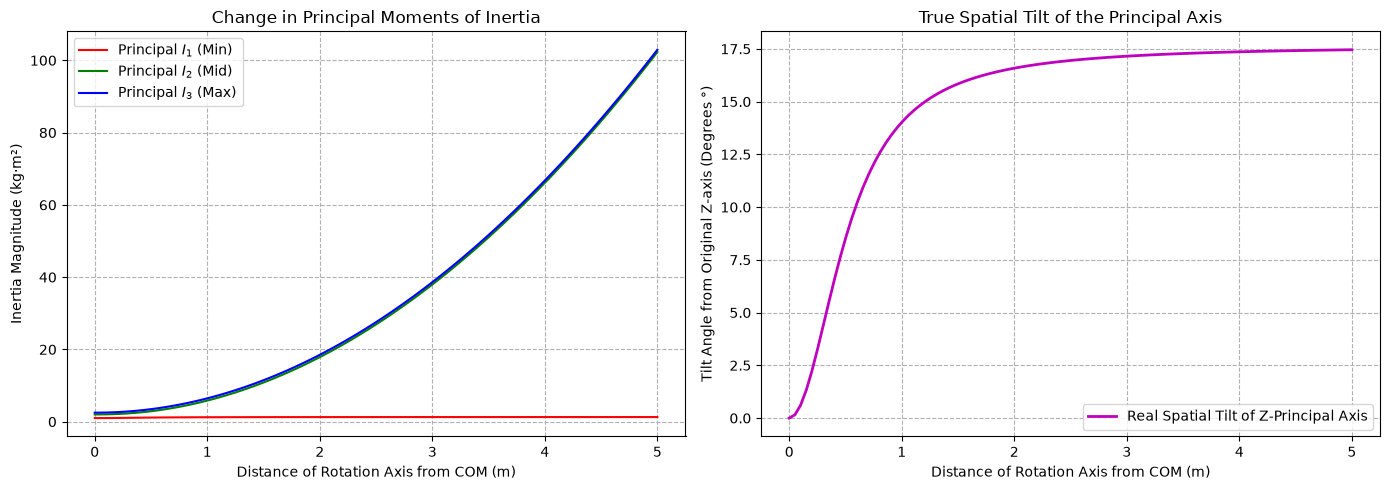

Reproduction of Abdulghany (2017) Sample Calculation

Cuboid tensor I1' / (mu*r^2):
[[ 48.984401   0.         0.      ]
 [  0.        22.017942 -11.610765]
 [  0.       -11.610765  29.633126]]

Cylinder tensor I2' / (mu*r^2):
[[ 51.049339   0.         0.      ]
 [  0.        42.179368 -14.783286]
 [  0.       -14.783286  10.440768]]

Total tensor I' / (mu*r^2):
[[100.033741   0.         0.      ]
 [  0.        64.19731  -26.394051]
 [  0.       -26.394051  40.073893]]

Paper Eq. (23):
[[100.034   0.      0.   ]
 [  0.     64.197 -26.394]
 [  0.    -26.394  40.074]]

Difference from paper's rounded values:
[[-0.000259  0.        0.      ]
 [ 0.        0.00031  -0.000051]
 [ 0.       -0.000051 -0.000107]]

Maximum absolute difference:
0.00031029805393245624

Result:
The sample calculation is reproduced successfully within rounding error.
Monte Carlo Geometry Verification
Total COM from geometry: [0.       1.319703 2.199504]

Paper rounded tensor:
[[100.034   0.      0.   ]
 [  0.     64.

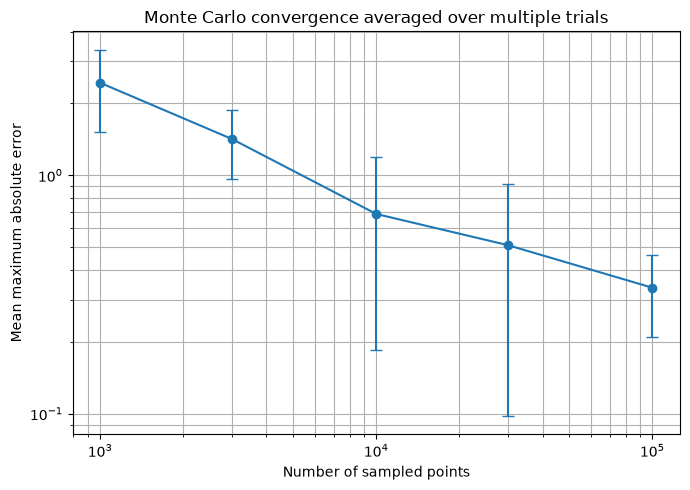

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 기초 역학 연산 함수 정의 (논문 기반)
# =====================================================================

def get_skew_matrix(v):
    x, y, z = v
    return np.array([
        [ 0, -z,  y],
        [ z,  0, -x],
        [-y,  x,  0]
    ])

def get_tensor_product_matrix(A, B):
    return -0.5 * (np.dot(get_skew_matrix(A), get_skew_matrix(B)) +
                   np.dot(get_skew_matrix(B), get_skew_matrix(A)))

def transform_inertia_tensor(I, M, R, C):
    return I + M * get_tensor_product_matrix(R, R) - 2 * M * get_tensor_product_matrix(R, C)


# =====================================================================
# 2. 물리 시스템 및 회전축 이동 시나리오 설정
# =====================================================================
M = 3.0  # 질량 (kg)
C_com = np.array([0.0, 0.0, 0.0])

# 초기 주축이 고유 좌표계 X, Y, Z와 일치하는 고유 관성 텐서
I_com = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 2.0, 0.0],
    [0.0, 0.0, 2.5]
])

steps = 100
x_positions = np.linspace(0, 5, steps)

principal_moments = []
spatial_tilt_angles = []  # 실제 공간적 뒤틀림 각도 (원래 Z축 기준)

# 고유벡터의 물리적 연속성을 추적하기 위한 초기 기준 벡터 (초기 Z축 주축)
reference_axis = np.array([0, 0, 1])

# =====================================================================
# 3. 실시간 루프 연산 (물리적 시나리오 및 고유벡터 추적 보완)
# =====================================================================
for x in x_positions:
    # 💡 물리적 보완: Z축 성분도 이동시켜 비대각 성분(I_xz, I_yz)을 활성화시킵니다.
    # 이래야 주축이 실제로 3차원 공간 상에서 '뒤틀리는' 물리 현상이 일어납니다.
    R = np.array([x, 0.5 * x, 0.3 * x])

    # 새로운 축에서의 관성 텐서 계산
    I_shifted = transform_inertia_tensor(I_com, M, R, C_com)

    # 고유값과 고유벡터 계산
    eigenvalues, eigenvectors = np.linalg.eig(I_shifted)

    # 💡 수치적 보완: 크기순 정렬을 하되 주모멘트 기록용으로만 쓰고,
    # 각도 계산 시에는 원래 Z축 방향 고유벡터가 어떻게 움직였는지 '방향성'을 기준으로 추적합니다.
    sort_idx = np.argsort(eigenvalues)
    principal_moments.append(eigenvalues[sort_idx])

    # 현재 계산된 3개의 고유벡터 중 원래 초기 reference_axis([0,0,1])와 가장 정렬된 벡터 찾기
    best_match_idx = np.argmax([abs(np.dot(eigenvectors[:, i], reference_axis)) for i in range(3)])
    tracked_axis = eigenvectors[:, best_match_idx]

    # 원래 Z축 방향 주축이 공간적으로 얼마나 기울어졌는지 각도 계산
    dot_product = np.dot(tracked_axis, reference_axis)
    angle = np.degrees(np.arccos(np.clip(abs(dot_product), -1.0, 1.0)))
    spatial_tilt_angles.append(angle)

principal_moments = np.array(principal_moments)


# =====================================================================
# 4. 데이터 시각화
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 [1]: 크기순 주관성 모멘트 연속 변화 (Crossing 없이 매끄럽게 플로팅)
ax1.plot(x_positions, principal_moments[:, 0], 'r-', label='Principal $I_1$ (Min)')
ax1.plot(x_positions, principal_moments[:, 1], 'g-', label='Principal $I_2$ (Mid)')
ax1.plot(x_positions, principal_moments[:, 2], 'b-', label='Principal $I_3$ (Max)')
ax1.set_title("Change in Principal Moments of Inertia", fontsize=12)
ax1.set_xlabel("Distance of Rotation Axis from COM (m)", fontsize=10)
ax1.set_ylabel("Inertia Magnitude (kg·m²)", fontsize=10)
ax1.grid(True, linestyle='--')
ax1.legend()

# 그래프 [2]: 진정한 의미의 주축 공간적 뒤틀림 각도 변위
ax2.plot(x_positions, spatial_tilt_angles, 'm-', linewidth=2, label='Real Spatial Tilt of Z-Principal Axis')
ax2.set_title("True Spatial Tilt of the Principal Axis", fontsize=12)
ax2.set_xlabel("Distance of Rotation Axis from COM (m)", fontsize=10)
ax2.set_ylabel("Tilt Angle from Original Z-axis (Degrees °)", fontsize=10)
ax2.grid(True, linestyle='--')
ax2.legend()

plt.tight_layout()
plt.show()

import numpy as np

np.set_printoptions(precision=6, suppress=True)

# =====================================================================
# Reproduction of Abdulghany (2017) Sample Calculation
# Generalization of Parallel Axis Theorem for Rotational Inertia
# =====================================================================

def bracket_matrix(A, B):
    """
    Paper Eq. (13): symmetric matrix [(A, B)]
    Off-diagonal terms have negative signs.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    xA, yA, zA = A
    xB, yB, zB = B

    return np.array([
        [yA*yB + zA*zB, -0.5*(xA*yB + yA*xB), -0.5*(xA*zB + zA*xB)],
        [-0.5*(xA*yB + yA*xB), xA*xB + zA*zB, -0.5*(yA*zB + zA*yB)],
        [-0.5*(xA*zB + zA*xB), -0.5*(yA*zB + zA*yB), xA*xB + yA*yB]
    ])

def generalized_parallel_axis(I_ref, M, R, C):
    """
    Paper Eq. (14):
        I' = I + M[(R, R)] - 2M[(R, C)]
    """
    return I_ref + M * bracket_matrix(R, R) - 2 * M * bracket_matrix(R, C)


# =====================================================================
# 1. Dimensionless setting
# 논문 결과는 mu*r^2 단위로 제시되므로, 계산 편의를 위해 mu = 1, r = 1로 둔다.
# =====================================================================

mu = 1.0
r = 1.0
pi = np.pi

# Paper Eq. (15)
# M1: cuboid mass = 4mu
# M2: cylinder mass = pi*mu
M1 = 4 * mu
M2 = pi * mu


# =====================================================================
# 2. Cuboid part
# Cuboid dimensions: 2r x 2r x 8r
# Paper Eq. (17):
# I1 = 4*mu*r^2 * diag(68/12, 8/12, 68/12)
# =====================================================================

I1_center = 4 * mu * r**2 * np.diag([
    68/12,
    8/12,
    68/12
])

# Paper:
# R1 = pi*r/(4+pi) * (0, 3, 5)
R1 = (pi * r / (4 + pi)) * np.array([0, 3, 5])

# The cuboid reference point is its own center of mass, so C1 = 0.
C1 = np.array([0.0, 0.0, 0.0])

# Paper Eq. (16)
I1_shifted = generalized_parallel_axis(I1_center, M1, R1, C1)


# =====================================================================
# 3. Cylinder part
# Cylinder radius: r, length: 8r
# Paper Eq. (20):
# I2 = pi*mu*r^2 * diag(67/12, 67/12, 1/2)
# =====================================================================

I2_center = pi * mu * r**2 * np.diag([
    67/12,
    67/12,
    1/2
])

# Paper:
# R2 = 4*r/(4+pi) * (0, 3, 5)
R2 = (4 * r / (4 + pi)) * np.array([0, 3, 5])

# The cylinder reference point is its own center of mass, so C2 = 0.
C2 = np.array([0.0, 0.0, 0.0])

# Paper Eq. (19)
I2_shifted = generalized_parallel_axis(I2_center, M2, R2, C2)


# =====================================================================
# 4. Compound object
# Paper Eq. (22): I_total = I1' + I2'
# =====================================================================

I_total = I1_shifted + I2_shifted

# Express in units of mu*r^2
I_total_dimensionless = I_total / (mu * r**2)

# Paper Eq. (23), from the paper:
I_paper = np.array([
    [100.034, 0.000, 0.000],
    [0.000, 64.197, -26.394],
    [0.000, -26.394, 40.074]
])

print("=" * 70)
print("Reproduction of Abdulghany (2017) Sample Calculation")
print("=" * 70)

print("\nCuboid tensor I1' / (mu*r^2):")
print(I1_shifted / (mu * r**2))

print("\nCylinder tensor I2' / (mu*r^2):")
print(I2_shifted / (mu * r**2))

print("\nTotal tensor I' / (mu*r^2):")
print(I_total_dimensionless)

print("\nPaper Eq. (23):")
print(I_paper)

print("\nDifference from paper's rounded values:")
print(I_total_dimensionless - I_paper)

print("\nMaximum absolute difference:")
print(np.max(np.abs(I_total_dimensionless - I_paper)))

print("\nResult:")
if np.max(np.abs(I_total_dimensionless - I_paper)) < 1e-3:
    print("The sample calculation is reproduced successfully within rounding error.")
else:
    print("The result does not match the paper. Check signs and vector definitions.")


import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

# =====================================================================
# Monte Carlo / Numerical Integration Verification
# Directly sample the cuboid + cylinder geometry from the original paper
# and compute the inertia tensor without using Eq. (14).
# =====================================================================

def sample_cuboid(n, r=1.0, center=np.array([0.0, 0.0, 0.0]), rng=None):
    """
    Sample n random points inside the cuboid.
    Cuboid dimensions in the paper:
        x length = 2r
        y length = 8r
        z length = 2r
    The cuboid is centered at 'center'.
    """
    if rng is None:
        rng = np.random.default_rng()

    half_lengths = np.array([r, 4*r, r])
    points = rng.uniform(-half_lengths, half_lengths, size=(n, 3))
    return points + center


def sample_cylinder_z(n, r=1.0, length=8.0, center=np.array([0.0, 0.0, 0.0]), rng=None):
    """
    Sample n random points inside a cylinder whose axis is parallel to the z-axis.
    Cylinder in the paper:
        radius = r
        length = 8r
    """
    if rng is None:
        rng = np.random.default_rng()

    theta = rng.uniform(0, 2*np.pi, n)
    radius = r * np.sqrt(rng.uniform(0, 1, n))

    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    z = rng.uniform(-length/2, length/2, n)

    points = np.column_stack([x, y, z])
    return points + center


def compute_weighted_inertia_tensor(masses, coords):
    """
    Direct inertia tensor calculation using the paper's sign convention:
    diagonal: Ixx, Iyy, Izz
    off-diagonal: -sum(mxy), -sum(mxz), -sum(myz)
    """
    I = np.zeros((3, 3))

    for m, r_vec in zip(masses, coords):
        x, y, z = r_vec

        I[0, 0] += m * (y**2 + z**2)
        I[1, 1] += m * (x**2 + z**2)
        I[2, 2] += m * (x**2 + y**2)

        I[0, 1] -= m * x * y
        I[1, 0] -= m * x * y

        I[0, 2] -= m * x * z
        I[2, 0] -= m * x * z

        I[1, 2] -= m * y * z
        I[2, 1] -= m * y * z

    return I


# =====================================================================
# 1. Paper geometry and exact analytic result
# =====================================================================

mu = 1.0
r = 1.0
pi = np.pi

# Paper masses
M_cuboid = 4 * mu
M_cylinder = pi * mu
M_total = M_cuboid + M_cylinder

# Centers of each component
cuboid_center = np.array([0.0, 0.0, 0.0])

# From the paper, the displacement from cuboid center to cylinder center is:
# D = r(0, 3, 5)
cylinder_center = np.array([0.0, 3.0*r, 5.0*r])

# Exact center of mass of the total compound object
COM_total = (M_cuboid * cuboid_center + M_cylinder * cylinder_center) / M_total

# Exact analytic result from the paper, Eq. (23), in units of mu*r^2
I_paper_rounded = np.array([
    [100.034, 0.000, 0.000],
    [0.000, 64.197, -26.394],
    [0.000, -26.394, 40.074]
]) * mu * r**2

print("=" * 70)
print("Monte Carlo Geometry Verification")
print("=" * 70)
print(f"Total COM from geometry: {COM_total}")
print("\nPaper rounded tensor:")
print(I_paper_rounded)


# =====================================================================
# 2. One Monte Carlo verification with many sampled points
# =====================================================================

rng = np.random.default_rng(42)

N_total = 60000
N_cuboid = N_total // 2
N_cylinder = N_total - N_cuboid

cuboid_points = sample_cuboid(N_cuboid, r=r, center=cuboid_center, rng=rng)
cylinder_points = sample_cylinder_z(N_cylinder, r=r, length=8*r, center=cylinder_center, rng=rng)

all_points = np.vstack([cuboid_points, cylinder_points])

# Each sampled point represents equal fraction of its component mass
sample_masses = np.concatenate([
    np.full(N_cuboid, M_cuboid / N_cuboid),
    np.full(N_cylinder, M_cylinder / N_cylinder)
])

# Shift all sampled points to the total COM
points_relative_to_COM = all_points - COM_total

# Direct numerical inertia tensor
I_monte_carlo = compute_weighted_inertia_tensor(sample_masses, points_relative_to_COM)

print("\nMonte Carlo direct tensor:")
print(I_monte_carlo)

print("\nDifference from paper rounded tensor:")
print(I_monte_carlo - I_paper_rounded)

max_abs_error = np.max(np.abs(I_monte_carlo - I_paper_rounded))
relative_error = max_abs_error / np.max(np.abs(I_paper_rounded))

print(f"\nMaximum absolute error: {max_abs_error:.6f}")
print(f"Relative error: {relative_error:.6%}")

# =====================================================================
# 3. Improved convergence test
# Average over multiple Monte Carlo trials for each sample size
# =====================================================================

sample_sizes = [1000, 3000, 10000, 30000, 100000]
num_trials = 10

mean_errors = []
std_errors = []

for N in sample_sizes:
    trial_errors = []

    for trial in range(num_trials):
        # Different random seed for each trial
        rng = np.random.default_rng(1000 + trial)

        N_cuboid = N // 2
        N_cylinder = N - N_cuboid

        # Randomly sample the cuboid and cylinder
        cuboid_points = sample_cuboid(
            N_cuboid,
            r=r,
            center=cuboid_center,
            rng=rng
        )

        cylinder_points = sample_cylinder_z(
            N_cylinder,
            r=r,
            length=8*r,
            center=cylinder_center,
            rng=rng
        )

        all_points = np.vstack([cuboid_points, cylinder_points])

        # Each sampled point represents an equal fraction of its part's mass
        sample_masses = np.concatenate([
            np.full(N_cuboid, M_cuboid / N_cuboid),
            np.full(N_cylinder, M_cylinder / N_cylinder)
        ])

        # Shift all sampled points to the total center of mass
        points_relative_to_COM = all_points - COM_total

        # Directly compute inertia tensor from sampled points
        I_mc = compute_weighted_inertia_tensor(
            sample_masses,
            points_relative_to_COM
        )

        # Compare with the paper's rounded tensor
        error = np.max(np.abs(I_mc - I_paper_rounded))
        trial_errors.append(error)

    mean_errors.append(np.mean(trial_errors))
    std_errors.append(np.std(trial_errors))

print("\nImproved convergence test with averaged Monte Carlo sampling:")
for N, mean_err, std_err in zip(sample_sizes, mean_errors, std_errors):
    print(
        f"N = {N:6d}, "
        f"mean max abs error = {mean_err:.6f}, "
        f"std = {std_err:.6f}"
    )

# Plot averaged convergence result
plt.figure(figsize=(7, 5))
plt.errorbar(
    sample_sizes,
    mean_errors,
    yerr=std_errors,
    marker='o',
    capsize=4
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of sampled points")
plt.ylabel("Mean maximum absolute error")
plt.title("Monte Carlo convergence averaged over multiple trials")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()